## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains ## Will become depreciated 
from shapely import contains_xy         ## Use this instead...
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

# To transform coordinates from lat lon to x y 
from pyproj import Transformer

# To ensure only continuous ocean/ice shelf regions can be included
from skimage.segmentation import flood, flood_fill

## Set variables 

In [2]:
# Set the filepaths and any variables 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'

# Neural network filepaths 
path_model = '/bettik/ockendeh/NEMO_simulations/models/'
path_norm_metrics = '/bettik/ockendeh/NEMO_simulations/models/'

# And the location of the output files 
filepath_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'
simulation = 'DUM001' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 

# Any parameters which need to be set 
# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'
join_ice_shelves = True

# Set the filepaths 
# The target grid mask 
filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
# The target grid geometry
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'

# Some potential masks from Clara 
fp_129basins = '/bettik/burgardc/DATA/FOR_HELEN/param_129basins_on_eORCA1.nc'
fp_519basins = '/bettik/burgardc/DATA/FOR_HELEN/basins_for_param_v5_raster_extrapolate_setgrid.nc'

In [3]:
basin129 = xr.open_dataset(fp_129basins)
basins129 = basin129.basin.sel(y = slice(0,110))
basin519 = xr.open_dataset(fp_519basins)

In [4]:
# We have basins129 with coordinates nav_lon, nav_lat and dimensions y:110, x: 360
# And we'd like basins129_025 with coordinates lon, lat and dimensions y:439, x:1440 
# And we'd like to use a kdtree 
#plt.pcolor(basin519.Band1)

In [5]:
masks025 = xr.open_dataset(filepath_mask)
#masks025.basins_NEMO

In [6]:
#masks025.lon.values

In [7]:
# Convert the basin129 on eORCA1 grid to basins on eORCA025 grid 
transformer = Transformer.from_crs("epsg:4326","epsg:3031", always_xy=True)

# Extract coordinate values from the basin129
lon0 = basins129.nav_lon.values
lat0 = basins129.nav_lat.values
# Convert to x and y
x0,y0 = transformer.transform(lon0, lat0)
# Prepare KDTree
pts0 = np.column_stack([x0.ravel(), y0.ravel()])
tree = cKDTree(pts0)
# Extract coordinates from the target eORCA025 grid
lon_new = masks025.lon.values
lat_new = masks025.lat.values
xnew,ynew = transformer.transform(lon_new, lat_new)
pts_new = np.column_stack([xnew.ravel(), ynew.ravel()])
# Query KD tree and then reshape to the correct eORCA025 grid 
dist, idx = tree.query(pts_new)
data0 = basins129.values.ravel()
basins129_025 = data0[idx].reshape(lat_new.shape)

In [8]:
# Convert the basin129 on eORCA1 grid to basins on eORCA025 grid 
transformer = Transformer.from_crs("epsg:4326","epsg:3031", always_xy=True)

# Extract coordinate values from the basin129
x0,y0 = np.meshgrid(basin519.x.values, basin519.y.values)
# Prepare KDTree
pts0 = np.column_stack([x0.ravel(), y0.ravel()])
tree = cKDTree(pts0)
# Extract coordinates from the target eORCA025 grid
lon_new = masks025.lon.values
lat_new = masks025.lat.values
xnew,ynew = transformer.transform(lon_new, lat_new)
pts_new = np.column_stack([xnew.ravel(), ynew.ravel()])
# Query KD tree and then reshape to the correct eORCA025 grid 
dist, idx = tree.query(pts_new)
idx.shape
data0 = basin519.Band1.values.ravel()
basins519_025 = data0[idx].reshape(lat_new.shape)

In [9]:
# Remap onto 0-133 rather than having random gaps (doesn't matter but slightly neater?)
uniq = np.unique(basins519_025)
inv = np.zeros(int(uniq.max()) + 1, dtype=int)
inv[uniq.astype(int)] = np.arange(len(uniq))
remapped = inv[basins519_025.astype(int)]


In [10]:
# Load in the TS grid 
gridT2 = load_TSmelt_normal(filepath_nemo_output)
# Load in the mask for the ocean region 
bmach_masks = xr.open_dataset(filepath_eORCA1_bmach_masks)
mask_nocavs = bmach_masks.mask_nocavs.values
bmach_masks.close()

# Load in the mask and geometry 
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, 
                                              filepath_mask, 
                                              join_ice_shelves = join_ice_shelves)
# Rename the dimensions of basins merged to be x and y 
if 'y_grid_T' in basins_merged.dims:
    basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int)
# Load in the coordinates for the grid 
coords = load_gridcoords(filepath_nemo_output)
# The basins mask for the NEMO 025 grid  
basins_NEMO = masks.basins_NEMO.values
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
basin_nos = np.arange(1,156, dtype = 'float32')

You have loaded T and S: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc
Ice shelves joined, as requested
You have loaded coordinates: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only


In [11]:
plot_comparison = False
if plot_comparison == True:
    fig, ax = plt.subplots(1,2, figsize = (20,8))
    ax[0].pcolor(basins129_025)#*masks025.open_cavities_nan)
    ax[1].pcolor(masks025.basins_NEMO)#*masks025.open_cavities_nan)
    titles = 'Clara\'s mask', 'Nico\'s mask'
    for i in range(2):
        ax[i].set_title(titles[i], fontsize = 30, fontweight = 'bold')
        ax[i].set_xticks([])
        ax[i].set_yticks([])

In [36]:
np.savetxt('remapped.txt', remapped, delimiter = ',')
np.savetxt('original.txt', basins_NEMO, delimiter = ',')

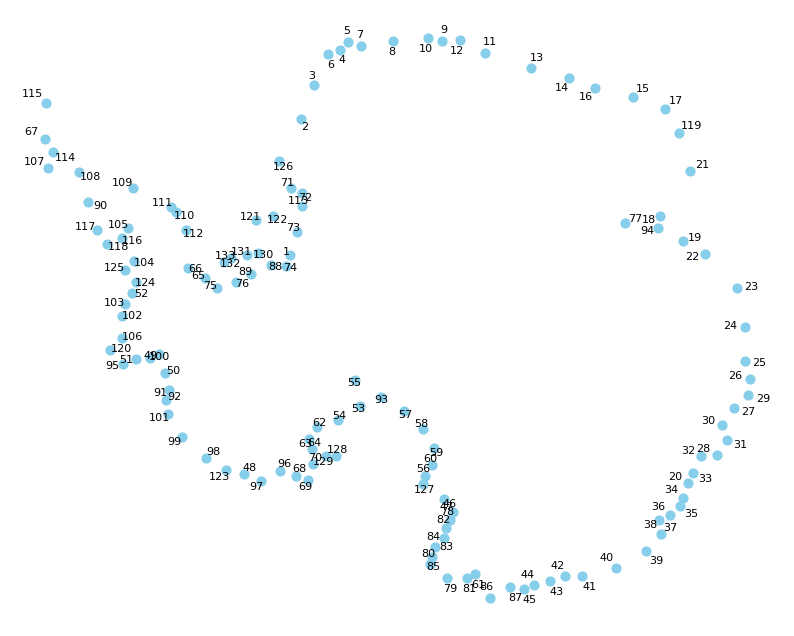

In [32]:
plot_basin_nos_map = True
if plot_basin_nos_map == True:
    fig, ax = plt.subplots(1,1, figsize = (10,8))
    for kk in range(len(basin_nos)):
        i = basin_nos[kk]
        #mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
        mask_basin_cavs = (remapped == i) & (masks.closed_cavities == 1)
        # Extract these points 
        idx = np.where(mask_basin_cavs == 1)
        lat_cavs = masks.lat.values[idx]
        lon_cavs = masks.lon.values[idx]
        # Transform to x and y
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
        if len(x_cavs[~np.isnan(x_cavs)]) > 0:
            plt.scatter(np.mean(x_cavs), np.mean(y_cavs), s = 40, c = 'skyblue')
            if  np.mod(i,2) == 1: 
                plt.annotate(int(i), xy = (0,0), xytext = (int(np.nanmean(x_cavs)*1.04), int(np.nanmean(y_cavs)*1.04)), fontsize = 8, ha = 'center', va = 'center')
            else:
              plt.annotate(int(i), xy = (0,0), xytext = (int(np.nanmean(x_cavs)*0.96), int(np.nanmean(y_cavs)*0.96)), fontsize = 8, ha = 'center', va = 'center')  
    ax.axis('off');

In [31]:
for i in range(len(np.unique(masks.basins_NEMO))):
    print(np.unique(masks.basins_NEMO)[i], np.sum((masks.basins_NEMO == np.unique(masks.basins_NEMO)[i]) * geoms.areas * geoms.fraction)/(1000*1000))

1.0 <xarray.DataArray ()> Size: 8B
array(3162.91103471)
2.0 <xarray.DataArray ()> Size: 8B
array(7528.26061233)
3.0 <xarray.DataArray ()> Size: 8B
array(19562.29603839)
4.0 <xarray.DataArray ()> Size: 8B
array(1922.1315736)
5.0 <xarray.DataArray ()> Size: 8B
array(0.99923677)
6.0 <xarray.DataArray ()> Size: 8B
array(2175.9085179)
7.0 <xarray.DataArray ()> Size: 8B
array(6737.24531366)
8.0 <xarray.DataArray ()> Size: 8B
array(7378.23337638)
9.0 <xarray.DataArray ()> Size: 8B
array(28474.32638582)
10.0 <xarray.DataArray ()> Size: 8B
array(7.49089941)
11.0 <xarray.DataArray ()> Size: 8B
array(7044.1437317)
12.0 <xarray.DataArray ()> Size: 8B
array(1998.50124344)
13.0 <xarray.DataArray ()> Size: 8B
array(16219.65664787)
14.0 <xarray.DataArray ()> Size: 8B
array(5735.13795609)
15.0 <xarray.DataArray ()> Size: 8B
array(32370.72346956)
16.0 <xarray.DataArray ()> Size: 8B
array(4468.63496935)
17.0 <xarray.DataArray ()> Size: 8B
array(501.5264761)
18.0 <xarray.DataArray ()> Size: 8B
array(1280.

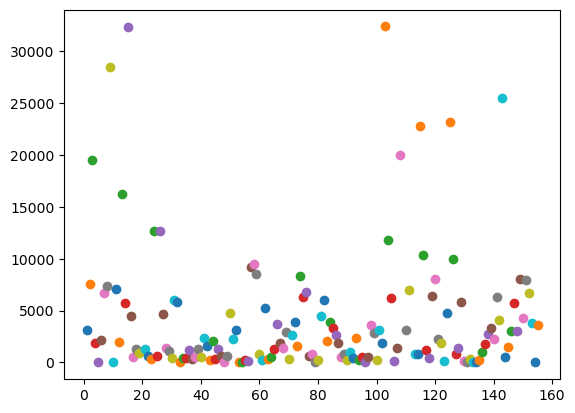

In [30]:
for i in range(len(np.unique(masks.basins_NEMO))):
    plt.scatter(np.unique(masks.basins_NEMO)[i], np.sum((masks.basins_NEMO == np.unique(masks.basins_NEMO)[i]) * geoms.areas * geoms.fraction)/(1000*1000))

In [24]:
np.sum((masks.basins_NEMO == 113) * geoms.areas)/(1000*1000)

<xarray.DataArray ()> Size: 8B
array(16641.69633062)

In [13]:
# Regions where it is acceptable to extract ocean profiles 
iy, ix = np.where((mask_nocavs == 1))
# coordinates of those cells
lat_ocean = coords.nav_lat.values[iy, ix]
lon_ocean = coords.nav_lon.values[iy, ix]
# Transform to x and y
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_ocean, y_ocean = transformer.transform(lat_ocean, lon_ocean)
# Stack to prepare for the KDTree
ocean_points = np.column_stack((x_ocean, y_ocean))
# Create KDTree
tree = cKDTree(ocean_points)

In [14]:
# To look at which ocean cells are extracted for each individual basin
#for kk in range(len(np.unique(remapped))):
for kk in range(131,137):
    #kk = 100
    #i = basin_nos[kk]
    #i = 104 #(A good example where it comes around the corner)
    #i = 125 ## AAAAh George VI
    i = np.unique(remapped)[kk]
    #i = 105
    print(i)
    #mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    #mask_basin_cavs = (basins129_025 == i) & (masks.closed_cavities == 1)
    mask_basin_cavs = (remapped == i) & (masks.closed_cavities == 1)
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    ocean_edge_illus = np.zeros_like(mask_nocavs)
    # If you allow all the nearest cells
    # And fill the cells found with the kd-tree
    for k in range(len(idx)):
        ocean_edge_illus[iy[idx[k]], ix[idx[k]]] = 1

    # Only allow cells where the distance is less than 1.5 times the minimum distance 
    # Should allow cells which are adjacent or as close to adjacent as possible
    idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
    for k in range(len(idxn)):
        ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    
    # Convert to polar stereographic coordinates 
    coords_x, coords_y = transformer.transform(coords.nav_lat, coords.nav_lon)
    # Calculate mean and range of cavity points
    mean_xcavs, mean_ycavs = np.mean(x_cavs), np.mean(y_cavs)
    rang_xcavs, rang_ycavs = np.max(x_cavs) - np.min(x_cavs), np.max(y_cavs) - np.min(y_cavs)
    rang = np.max((rang_xcavs, rang_ycavs))
    if rang < 500000:
        rang = 500000
    # Create mask of the relevant region)
    mask_close = (coords_x < (np.max(x_cavs) + rang*0.3)) & (coords_x > (np.min(x_cavs) - rang*0.3)) & \
                 (coords_y < (np.max(y_cavs) + rang*0.3)) & (coords_y > (np.min(y_cavs) - rang*0.3)) 
    
    # Ocean cells 
    iy2, ix2 = np.where(ocean_edge_basin == 1)
    x_oceanhere = []
    y_oceanhere = []
    for jkl in (0,1,2,3,0):
        lat_oceanhere = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy2, ix2]
        lon_oceanhere = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy2, ix2]
        x_jkl, y_jkl = transformer.transform(lat_oceanhere, lon_oceanhere)
        x_oceanhere.append(x_jkl)
        y_oceanhere.append(y_jkl)
    # Ocean cells with old code  
    iy5, ix5 = np.where(ocean_edge_illus == 1)
    x_illushere = []
    y_illushere = []
    for jkl in (0,1,2,3,0):
        lat_illushere = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy5, ix5]
        lon_illushere = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy5, ix5]
        x_jkl, y_jkl = transformer.transform(lat_illushere, lon_illushere)
        x_illushere.append(x_jkl)
        y_illushere.append(y_jkl)
    
    # All Bedmachine cells 
    iy3, ix3 = np.where((mask_close == 1) & (mask_nocavs == 1)) 
    x_grid = []
    y_grid = []
    for jkl in (0,1,2,3,0):
        lat_here = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy3, ix3]
        lon_here = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy3, ix3]
        x_jkl, y_jkl = transformer.transform(lat_here, lon_here)
        x_grid.append(x_jkl)
        y_grid.append(y_jkl)
    
    # Load in the bedmachine data for plotting
    # Filepath_bedmachine 
    filepath_bedmachine = '../AIAI_data/BedMachineAntarctica-v3.nc'
    bmach3 = xr.open_dataset(filepath_bedmachine)
    xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)
    
    fig, axs = plt.subplots(1,2, figsize = (11,7), width_ratios = (2.5,1))
    plt.subplots_adjust(wspace = 0)
    
    ax = axs[0]
    ax.fill(x_oceanhere, y_oceanhere, c = 'lightpink', zorder = 2, alpha = 1.0);
    ax.fill(x_illushere, y_illushere, c = 'hotpink', zorder = 1, alpha = 0.5);
    ax.plot(x_grid, y_grid, c = 'k', linewidth = 0.1, zorder = 10, alpha = 0.5);
    value = 3
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'mediumturquoise', \
              label = '', zorder = 0, alpha = 0.2)
    value = 2
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'lightgrey', \
              label = '', zorder = 0, alpha = 0.5)
    value = 0
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'paleturquoise', \
              label = 'Ocean', zorder = 0, alpha = 0.5)
    #ax.axis('equal')
    ax.set_xlim(np.min(x_cavs)-rang*0.2, np.max(x_cavs) + rang*0.2)
    ax.set_ylim(np.min(y_cavs)-rang*0.2, np.max(y_cavs) + rang*0.2)
    
    ax.scatter(x_cavs, y_cavs, zorder = 10)
    ax.set_xticks([]), ax.set_yticks([])
    
    ax = axs[1]
    ax.scatter(x_cavs, y_cavs, s = 0.05)
    ax.plot((np.min(x_cavs) - rang*0.2, np.min(x_cavs) - rang*0.2, \
             np.max(x_cavs) + rang*0.2, np.max(x_cavs) + rang*0.2, \
             np.min(x_cavs) - rang*0.2), \
            (np.min(y_cavs) - rang*0.2, \
             np.max(y_cavs) + rang*0.2, np.max(y_cavs) + rang*0.2, \
             np.min(y_cavs) - rang*0.2, np.min(y_cavs) - rang*0.2), c = 'red')
    value = 3
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.05, c = 'mediumturquoise', \
              label = '', zorder = 0, alpha = 0.2)
    ax.axis('equal')
    ax.set_xticks([]), ax.set_yticks([])
    ax.axis('off')
    
    fig.savefig('FIGURES/BASINS/basin_{}.jpg'.format(str(i).zfill(3)), dpi = 200, bbox_inches = 'tight')
    plt.close(fig)

131
132
133


IndexError: index 134 is out of bounds for axis 0 with size 134

In [ ]:
purple

In [ ]:
# To look at which ocean cells are extracted for each individual basin
plot_figure = True
if plot_figure == True:
    #kk = 100
    #i = basin_nos[kk]
    #i = 104 #(A good example where it comes around the corner)
    #i = 125 ## AAAAh George VI
    i = 115
    #i = 105
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    #mask_basin_cavs = (basins129_025 == i) & (masks.closed_cavities == 1)
    #mask_basin_cavs = (remapped == i) & (masks.closed_cavities == 1)
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    ocean_edge_illus = np.zeros_like(mask_nocavs)
    # If you allow all the nearest cells
    # And fill the cells found with the kd-tree
    for k in range(len(idx)):
        ocean_edge_illus[iy[idx[k]], ix[idx[k]]] = 1

    # Only allow cells where the distance is less than 1.5 times the minimum distance 
    # Should allow cells which are adjacent or as close to adjacent as possible
    idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
    for k in range(len(idxn)):
        ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    
    # Convert to polar stereographic coordinates 
    coords_x, coords_y = transformer.transform(coords.nav_lat, coords.nav_lon)
    # Calculate mean and range of cavity points
    mean_xcavs, mean_ycavs = np.mean(x_cavs), np.mean(y_cavs)
    rang_xcavs, rang_ycavs = np.max(x_cavs) - np.min(x_cavs), np.max(y_cavs) - np.min(y_cavs)
    rang = np.max((rang_xcavs, rang_ycavs))
    if rang < 500000:
        rang = 500000
    # Create mask of the relevant region)
    mask_close = (coords_x < (np.max(x_cavs) + rang*0.3)) & (coords_x > (np.min(x_cavs) - rang*0.3)) & \
                 (coords_y < (np.max(y_cavs) + rang*0.3)) & (coords_y > (np.min(y_cavs) - rang*0.3)) 
    
    # Ocean cells 
    iy2, ix2 = np.where(ocean_edge_basin == 1)
    x_oceanhere = []
    y_oceanhere = []
    for jkl in (0,1,2,3,0):
        lat_oceanhere = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy2, ix2]
        lon_oceanhere = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy2, ix2]
        x_jkl, y_jkl = transformer.transform(lat_oceanhere, lon_oceanhere)
        x_oceanhere.append(x_jkl)
        y_oceanhere.append(y_jkl)
    # Ocean cells with old code  
    iy5, ix5 = np.where(ocean_edge_illus == 1)
    x_illushere = []
    y_illushere = []
    for jkl in (0,1,2,3,0):
        lat_illushere = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy5, ix5]
        lon_illushere = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy5, ix5]
        x_jkl, y_jkl = transformer.transform(lat_illushere, lon_illushere)
        x_illushere.append(x_jkl)
        y_illushere.append(y_jkl)
    
    # All Bedmachine cells 
    iy3, ix3 = np.where((mask_close == 1) & (mask_nocavs == 1)) 
    x_grid = []
    y_grid = []
    for jkl in (0,1,2,3,0):
        lat_here = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy3, ix3]
        lon_here = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy3, ix3]
        x_jkl, y_jkl = transformer.transform(lat_here, lon_here)
        x_grid.append(x_jkl)
        y_grid.append(y_jkl)
    
    # Load in the bedmachine data for plotting
    # Filepath_bedmachine 
    filepath_bedmachine = '../AIAI_data/BedMachineAntarctica-v3.nc'
    bmach3 = xr.open_dataset(filepath_bedmachine)
    xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)
    
    fig, axs = plt.subplots(1,2, figsize = (11,7), width_ratios = (2.5,1))
    plt.subplots_adjust(wspace = 0)
    
    ax = axs[0]
    ax.fill(x_oceanhere, y_oceanhere, c = 'lightpink', zorder = 2, alpha = 1.0);
    ax.fill(x_illushere, y_illushere, c = 'hotpink', zorder = 1, alpha = 0.5);
    ax.plot(x_grid, y_grid, c = 'k', linewidth = 0.1, zorder = 10, alpha = 0.5);
    value = 3
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'mediumturquoise', \
              label = '', zorder = 0, alpha = 0.2)
    value = 2
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'lightgrey', \
              label = '', zorder = 0, alpha = 0.5)
    value = 0
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'paleturquoise', \
              label = 'Ocean', zorder = 0, alpha = 0.5)
    #ax.axis('equal')
    ax.set_xlim(np.min(x_cavs)-rang*0.2, np.max(x_cavs) + rang*0.2)
    ax.set_ylim(np.min(y_cavs)-rang*0.2, np.max(y_cavs) + rang*0.2)
    
    ax.scatter(x_cavs, y_cavs, zorder = 10)
    ax.set_xticks([]), ax.set_yticks([])
    
    ax = axs[1]
    ax.scatter(x_cavs, y_cavs, s = 0.05)
    ax.plot((np.min(x_cavs) - rang*0.2, np.min(x_cavs) - rang*0.2, \
             np.max(x_cavs) + rang*0.2, np.max(x_cavs) + rang*0.2, \
             np.min(x_cavs) - rang*0.2), \
            (np.min(y_cavs) - rang*0.2, \
             np.max(y_cavs) + rang*0.2, np.max(y_cavs) + rang*0.2, \
             np.min(y_cavs) - rang*0.2, np.min(y_cavs) - rang*0.2), c = 'red')
    value = 3
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.05, c = 'mediumturquoise', \
              label = '', zorder = 0, alpha = 0.2)
    ax.axis('equal')
    ax.set_xticks([]), ax.set_yticks([])
    ax.axis('off')
    
    #fig.savefig('FIGURES/howtoselectoceancells.jpg', dpi = 200, bbox_inches = 'tight')

In [ ]:
purple

## Compare my NEMO mask to Clara's mask 

In [ ]:
# Load in Clara's mask 
mask_clara = xr.open_dataset('/bettik/burgardc/DATA/FOR_HELEN/mask_unresolved_points_eORCA1_BedMachine2km.nc')
quad_melt = xr.open_dataset('/bettik/burgardc/DATA/FOR_HELEN/info_quad_meltparam_isf_129basins.nc')
xclara, yclara = np.meshgrid(mask_clara.x, mask_clara.y)

In [ ]:
fig, axs = plt.subplots(1,1, figsize = (10,10))
plt.subplots_adjust(wspace = 0.01)

# Plot the NEMO grid cell outlines 
pc = PolyCollection( polys, facecolors=colors, edgecolors=edge, linewidth = 0.2) 
axs.add_collection(pc)

# Plot the NEMO 1/4 degree cells resolved by the neural network 
xIC, yIC = transformer.transform(masks.lon.values[(fraction_IC > 0) & (nearest_total == 1)], \
                                 masks.lat.values[(fraction_IC > 0) & (nearest_total == 1)])
axs.scatter(xIC, yIC, s = 2, c = 'k', marker = 'o', label = 'Ice shelf resolved by neural network')

# Plot the BedMachine Antarctica v3 mask 
cmap = mcolors.ListedColormap(['mediumturquoise', 'lightcyan'])
im = axs.imshow(values[::5,::5], cmap = cmap, extent = bounds)
im.set_clim(0.5,2.5)

# Plot the points where clara will apply her parameterisation 
axs.scatter(xclara[mask_clara.unresolved_isf_points.values == True], \
            yclara[mask_clara.unresolved_isf_points == True], s = 0.1, marker = 'o', c = 'red')

which_region = 'Ross'

regions = {
    "PineIsland":     (-2.05e6, -1.45e6, -0.7e6, -0.2e6),
    "FilchnerRonne":  (-1.55e6, -0.45e6, 0e6, 1.1e6),
    "Brunt":          (-0.75e6, 0e6, 1.1e6, 2.3e6),
    "Amery":          (1.6e6, 2.3e6, 0.5e6, 1.0e6),
    "Ross":           (-0.6e6, 0.5e6, -1.4e6, -0.3e6),
}

bounds_h = regions[which_region]
axs.set_xlim(bounds_h[0],bounds_h[1])
axs.set_ylim(bounds_h[2],bounds_h[3])

axs.axis('off');

fig.savefig('FIGURES/' + which_region + '.jpg', dpi = 200, bbox_inches = 'tight')

In [ ]:
plt.pcolor(mask_clara.unresolved_isf_points)

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (40,40))
cmap = mcolors.ListedColormap(['mediumturquoise', 'lightcyan'])
im = plt.imshow(values[::5,::5], cmap = cmap, extent = bounds)

pc = PolyCollection( polys, facecolors=colors, edgecolors=edge, linewidth = 0.1) 
ax.add_collection(pc)

plt.plot((0,1),(0,1), color = 'grey', label = 'Ice shelf resolved in NEMO 1 degree')

xIC, yIC = transformer.transform(masks.lon.values[(fraction_IC > 0) & (nearest_total == 1)], \
                                 masks.lat.values[(fraction_IC > 0) & (nearest_total == 1)])
plt.scatter(xIC, yIC, s = 20, c = 'k', marker = 'o', label = 'Ice shelf resolved by neural network')

plt.scatter(0,0, color = 'mediumturquoise', label = 'Ice shelf (Bedmachine v3)', s = 20)
plt.scatter(0,0, color = 'lightcyan',       label = 'Land and grounded ice (Bedmachine v3)', s = 20)


plt.legend(loc = (0,1.01), fontsize = 40, markerscale = 10)
#xIC2, yIC2 = transformer.transform(masks.lon.values[masks.closed_cavities_nan == 1] , \
#                                 masks.lat.values[masks.closed_cavities_nan == 1])
#plt.scatter(xIC2, yIC2, s = 60, c = 'red', marker = 'o', zorder = 0)

im.set_clim(0.5,2.5)
ax.set_xlim(-1.5e6, -0.5e6)
ax.set_ylim(0e6, 1.0e6)
ax.axis('off')

#fig.savefig('FIGURES/legend.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (50,50))
cmap = mcolors.ListedColormap(['mediumturquoise', 'lightcyan'])
im = plt.imshow(values[::1,::1], cmap = cmap, extent = bounds)

pc = PolyCollection( polys, facecolors=colors, edgecolors=edge, linewidth = 0.1) 
ax.add_collection(pc)

#xIC, yIC = transformer.transform(masks.lon.values[fraction_IC > 0], masks.lat.values[fraction_IC > 0])
xIC, yIC = transformer.transform(masks.lon.values[(fraction_IC > 0) & (nearest_total == 1)], \
                                 masks.lat.values[(fraction_IC > 0) & (nearest_total == 1)])
plt.scatter(xIC, yIC, s = 0.05, c = 'k', marker = 'o')

im.set_clim(0.5,2.5)
ax.set_xlim(-2.7e6,2.8e6)
ax.set_ylim(-2.6e6, 2.6e6)
ax.axis('off')

plt.savefig('FIGURES/map.png', dpi = 500, bbox_inches = 'tight')

In [ ]:
# A very tedious map correction
fraction_IC[166, 433] = 1
fraction_IC[171, 432] = 0
fraction_IC[170, 432] = 0.2
fraction_IC[169, 432] = 0.4
fraction_IC[168, 433] = 0.6
fraction_IC[167, 433] = 0.8
fraction_IC[160:166, 433] = 1
fraction_IC[150:159, 434] = 1
fraction_IC[142:150, 435] = 1
fraction_IC[135:143, 436] = 1
fraction_IC[128:135, 437] = 1
fraction_IC[121:128, 438] = 1
fraction_IC[115:121, 439] = 1
fraction_IC[110:115, 440] = 1
fraction_IC[104:110, 441] = 1
fraction_IC[99:104, 442] = 1
fraction_IC[94:99, 443] = 1
fraction_IC[89:94, 444] = 1
fraction_IC[84:89, 445] = 1
fraction_IC[80:84, 446] = 1
fraction_IC[75:80, 447] = 1
fraction_IC[71:75, 448] = 1
fraction_IC[67:71, 449] = 1
fraction_IC[63:67, 450] = 1
fraction_IC[59:63, 451] = 1
fraction_IC[55:59, 452] = 1
fraction_IC[51:55, 453] = 1
fraction_IC[47:51, 454] = 1
fraction_IC[43:47, 455] = 1
fraction_IC[40:43, 456] = 1
fraction_IC[36:40, 457] = 1
fraction_IC[33:36, 458] = 1
fraction_IC[32, 458] = 0.8
fraction_IC[31, 459] = 0.6
fraction_IC[30, 459] = 0.5
fraction_IC[29, 459] = 0.4
fraction_IC[172:181, 432] = 0
fraction_IC[182:196, 431] = 0
fraction_IC[196:218, 430] = 0
fraction_IC[219:384, 429] = 0
fraction_IC[384:440, 429] = np.nan

In [ ]:

groundedice[33:36, 458] = 0
groundedice[36:40, 457] = 0
groundedice[40:43, 456] = 0
groundedice[43:47, 455] = 0
groundedice[47:51, 454] = 0
groundedice[51:55, 453] = 0
groundedice[55:59, 452] = 0
groundedice[59:63, 451] = 0
groundedice[63:67, 450] = 0
groundedice[67:71, 449] = 0
groundedice[71:75, 448] = 0
groundedice[75:80, 447] = 0
groundedice[80:84, 446] = 0
groundedice[84:89, 445] = 0
groundedice[89:94, 444] = 0
groundedice[94:99, 443] = 0
groundedice[99:104, 442] = 0
groundedice[104:110, 441] = 0
groundedice[110:115, 440] = 0
groundedice[115:121, 439] = 0
groundedice[121:128, 438] = 0
groundedice[128:135, 437] = 0
groundedice[135:142, 436] = 0
groundedice[142:150, 435] = 0
groundedice[150:159, 434] = 0
groundedice[160:169, 433] = 0
groundedice[170:181, 432] = 0
groundedice[181:196, 431] = 0
groundedice[196:218, 430] = 0
groundedice[218:384, 429] = 0
groundedice[383:438,429] = np.nan
groundedice[32, 458] = 0.2
groundedice[133,156] = 1
groundedice[213:215,798] = 1

In [ ]:
fraction_OO[170:181, 432] = 1
fraction_OO[181:196, 431] = 1
fraction_OO[196:218, 430] = 1
fraction_OO[218:384, 429] = 1
fraction_OO[383:438,429] = np.nan
fraction_OO[150,434] = 0
fraction_OO[121,438] = 0
fraction_OO[115,439] = 0
fraction_OO[133,156] = 0
fraction_OO[43,455] = 0
fraction_OO[213:215,798] = 0